<center><h1>DSCI-552 HOMEWORK 1</h1></center>
<br>
<center><font size="4">Classification Using KNN</font></center>
<center><font size="3"><strong>Mason(Mohan) Xing</font></center>
<center><font size="3"><strong>USCID:	6880083372</font></center>

In [1]:
# import dependencies
import os
import urllib
import zipfile
from tqdm import tqdm
from scipy.io import arff
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn import preprocessing
import math
import numpy as np
from numpy.linalg import inv,pinv
from math import sqrt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import DistanceMetric
from sklearn.metrics import plot_confusion_matrix,\
mean_squared_error, precision_score, recall_score, \
f1_score, roc_auc_score, confusion_matrix, classification_report,\
accuracy_score

### (a) Download the Vertebral Column Data Set from: https://archive.ics.uci.edu/ml/datasets/Vertebral+Column.
* You can run these lines to download the dataset

In [2]:
# # download original dataset
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip"
# file = "../data/vertebral_column_data.zip"
# urllib.request.urlretrieve(url, file)

# with zipfile.ZipFile(file, 'r') as zip_ref:
#     zip_ref.extractall("../data/vertebral_column_data")
#     zip_ref.close()

# os.remove(file)

### (b) Pre-Processing and Exploratory data analysis:
Since we only need to use column_2C.dat file in this homework, then we need to reterive the header from .arff file first

In [3]:
data0 = arff.loadarff('../data/vertebral_column_data/column_2C_weka.arff')
df_temp = pd.DataFrame(data0[0])
header = df_temp.columns
print(header)

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')


In [4]:
df = pd.read_table('../data/vertebral_column_data/column_2C.dat', header=None, sep = '\s+', names = header)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


In [5]:
# label class
data = df.copy()
dummy = pd.get_dummies(data['class'])
data = pd.concat([data, dummy], axis = 1)
data.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class,AB,NO
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB,1,0
1,39.06,10.06,25.02,29.00,114.41,4.56,AB,1,0
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB,1,0
3,69.30,24.65,44.31,44.64,101.87,11.21,AB,1,0
4,49.71,9.65,28.32,40.06,108.17,7.92,AB,1,0


* binary classification task NO=0 and AB=1

In [6]:
# drop the extra columns for ploting
data_new = data.drop(['class', 'NO'], axis=1)
data_new = data_new.rename(columns={"AB": "class"})
print(data_new.shape)
data_new.head()

(310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


### (b) i. Make scatterplots of the independent variables in the dataset. Use color to show Classes 0 and 1.

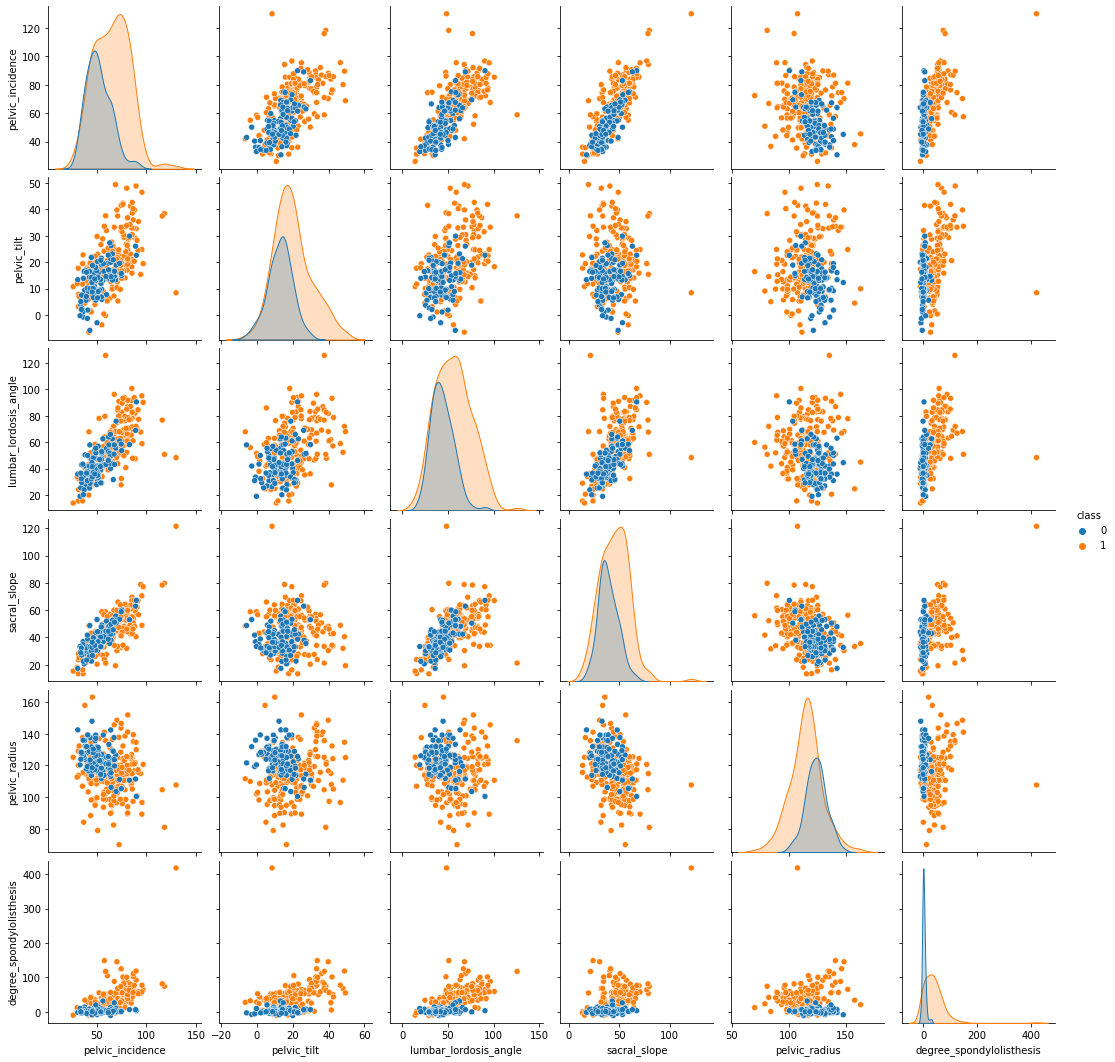

In [7]:
g = sns.pairplot(data_new, vars=header[0:6], hue='class', diag_kind="kde") # diag_kind{‘auto’, ‘hist’, ‘kde’, None}
# plt.show()

### (b) ii. Make boxplots for each of the independent variables. Use color to show Classes 0 and 1 (see ISLR p. 129).

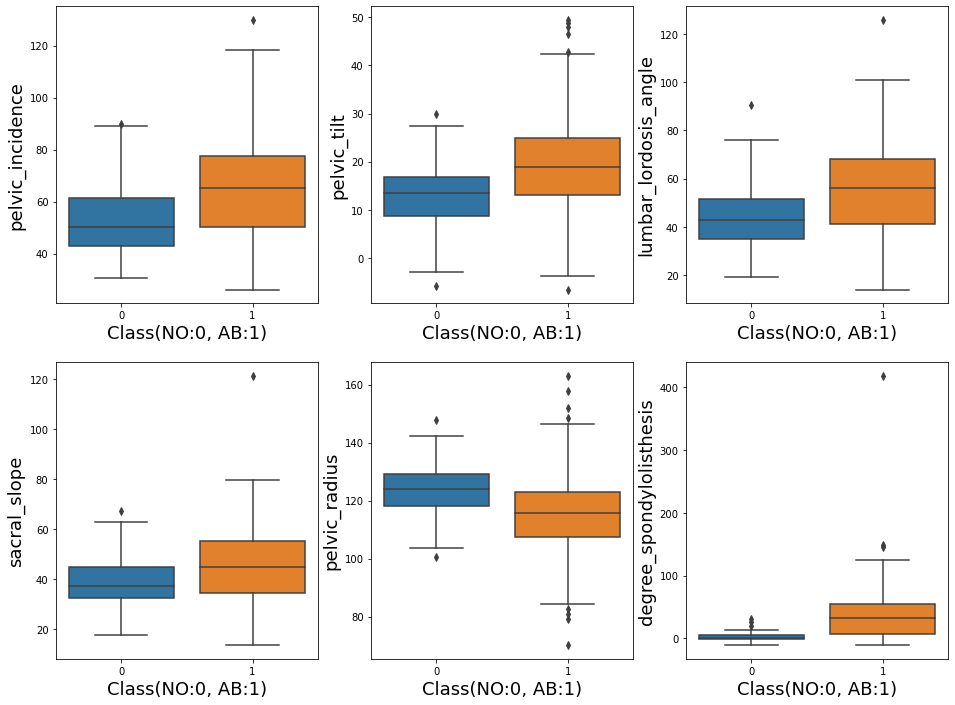

In [8]:
# fig, axes = plt.subplots(2,3, figsize=(16,10))
# plt.figure(figsize=(16,12))
fig, ax = plt.subplots(figsize=(16,12))
i=1
names = header[0:6]
for name in names:
    plt.subplot(2,3,i)
    
    g=sns.boxplot(y=name, x="class", data=data_new)
    g.set_xlabel("Class(NO:0, AB:1)",fontsize = 18)
    g.set_ylabel(name,fontsize = 18)
#     g.set_title("Plot", fontsize = 20)
    i+=1
# plt.show()

### (b) iii. Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set and the rest of the data as the test set.

In [9]:
# Create two tables based on class labels
df_NO = data_new.loc[data_new["class"]==0]
df_AB = data_new.loc[data_new["class"]==1]

# select desired data
df_NO_train = df_NO.iloc[0:70]
df_AB_train = df_AB.iloc[0:140]

# create train and test dataframe
df_train = pd.concat([df_NO_train, df_AB_train ], ignore_index=False).sort_index()
df_test = pd.concat([data_new, df_train], ignore_index=False).drop_duplicates(keep=False)

# Define split training/testing set and lables 
X_train = df_train.drop("class", axis=1)
X_test = df_test.drop("class", axis=1)

y_train = df_train["class"]
y_test = df_test["class"]

In [10]:
print("X_train.shape:")
print(X_train.shape)
X_train.head()

X_train.shape:
(210, 6)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92


In [11]:
print("X_test.shape:")
print(X_test.shape)
X_test.head()

X_test.shape:
(100, 6)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
140,69.56,15.40,74.44,54.16,105.07,29.70
141,89.50,48.90,72.00,40.60,134.63,118.35
142,85.29,18.28,100.74,67.01,110.66,58.88
143,60.63,20.60,64.54,40.03,117.23,104.86
144,60.04,14.31,58.04,45.73,105.13,30.41


In [12]:
print("y_train.shape:")
print(y_train.shape)
y_train.head()

y_train.shape:
(210,)


0    1
1    1
2    1
3    1
4    1
Name: class, dtype: uint8

In [13]:
print("y_test.shape:")
print(y_test.shape)
y_test.head()

y_test.shape:
(100,)


140    1
141    1
142    1
143    1
144    1
Name: class, dtype: uint8

### (c) Classification using KNN on Vertebral Column Data Set

### (c) i. Write code for k-nearest neighbors with Euclidean metric (or use a software package)

#### Method 1 (Practice only)

In [14]:
# calculate the Euclidean distance between two vectors
def euclidean_distance(row1, row2):
    distance = 0
    for i in range(len(row1)-1):
        distance += (row1[i] - row2[i])**2
    return sqrt(distance)

In [15]:
# Locate the most similar neighbors
def get_neighbors(train, test_row, num_neighbors):
    distances = list()
    for index,train_row in train.iterrows():
        dist = euclidean_distance(test_row, train_row)
        distances.append((train_row, dist))
        
    distances.sort(key=lambda tup: tup[1])
    neighbors = list()
    for i in range(num_neighbors):
        neighbors.append(distances[i][0])
    return neighbors

In [16]:
# Make a classification prediction with neighbors
def predict_classification(train, test_row, num_neighbors):
    neighbors = get_neighbors(train, test_row, num_neighbors)
    output_values = [row[-1] for row in neighbors]
    prediction = max(set(output_values), key=output_values.count)
    return prediction

In [17]:
row0 = df_train.iloc[0]
# test
predict_classification(df_train, row0, 4)

1.0

#### Method 2 Using Scikit Learn KNeighborsClassifier
* Euclidean distance (p = 2, metric='euclidean')

In [18]:
def knnclf(knn, k, X_train, X_test, y_train, y_test):
    temp_dict = {}
    knn.set_params(n_jobs=-1,n_neighbors=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    # calculate MSE
    train_error = mean_squared_error(y_train, y_train_pred, squared=True)
    test_error = mean_squared_error(y_test, y_test_pred, squared=True)
    # calculate error rate
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_error_rate = 1-train_accuracy
    test_error_rate = 1-test_accuracy
    #construct output dict
    temp_dict['k'] = k
    temp_dict['train_error'] = train_error
    temp_dict['test_error'] = test_error
    temp_dict['train_error_rate'] = train_error_rate
    temp_dict['test_error_rate'] = test_error_rate
    
    return temp_dict

### (C)ii. Test all the data in the test database with k nearest neighbors. Take decisions by majority polling. Plot train and test errors in terms of k for k ∈ { 208, 205, . . . ,7,4,1,} (in reverse order) 

In [19]:
k_set = list(range(208, 0, -3))
# declare classifier
# knn = KNeighborsClassifier(metric ='euclidean')
knn = KNeighborsClassifier(metric = 'euclidean')

result_list = []
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_cii = pd.DataFrame(result_list)

#calculate min k and min test error rate
min_test_error_rate_cii = min(df_cii.test_error_rate) 
min_test_error_cii = min(df_cii.test_error)
min_test_k_cii = (df_cii.loc[df_cii.test_error_rate == min_test_error_rate_cii]['k']).tolist()
min_test_k_cii_o = min_test_k_cii[0]

#calculate optimal k and min train error rate
min_train_error_rate_cii = min(df_cii.train_error_rate)
min_train_k_cii = (df_cii.loc[df_cii.train_error_rate == min_train_error_rate_cii]['k']).tolist()

# df_cii_report = df_cii.loc[(df_cii.test_error_rate == min_test_error_rate) | (df_cii.train_error_rate == min_train_error_rate) ]
# df_cii_report
# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}


#### -Plot train and test errors

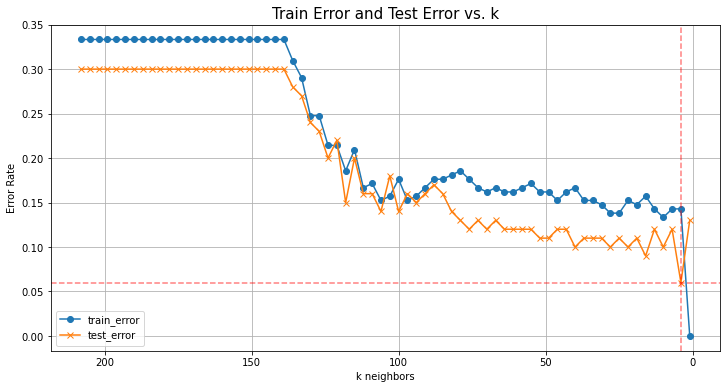

In [20]:
# making plot
plt.figure(figsize=(12, 6))     
plt.plot(k_set, df_cii.train_error_rate, marker='o', label="train_error")
plt.plot(k_set, df_cii.test_error_rate, marker="x", label="test_error")
for v in min_test_k_cii:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_cii, color='r', alpha=0.5, linestyle='--')
plt.gca().invert_xaxis()

plt.grid(True)
plt.title("Train Error and Test Error vs. k",fontsize=15)
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower left")
plt.show()

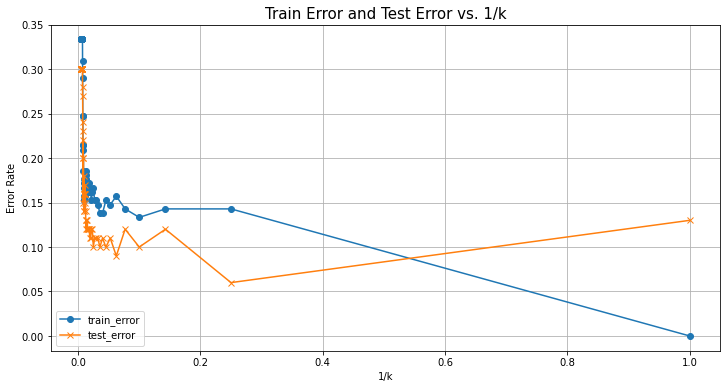

In [21]:
plt.figure(figsize=(12, 6))     
plt.plot(1/np.array(k_set), df_cii.train_error_rate, marker='o', label="train_error")
plt.plot(1/np.array(k_set), df_cii.test_error_rate, marker="x", label="test_error")
plt.grid(True)
plt.title("Train Error and Test Error vs. 1/k",fontsize=15)
plt.xlabel("1/k")
plt.ylabel("Error Rate")
plt.legend(loc="lower left")
plt.show()

In [22]:
# report
cii_k_report = df_cii.loc[df_cii.test_error_rate == min_test_error_rate_cii]
print("-"*55)
print("Report for Minimum Error of Euclidean when k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_cii_o))
print("-"*55)
print("Minimum test error rate: " + str(min_test_error_rate_cii))
print("-"*55)
print("Minimum train error rate: " + str(min_train_error_rate_cii))
print("-"*55)

-------------------------------------------------------
Report for Minimum Error of Euclidean when k = k*: 
-------------------------------------------------------
K*: 4
-------------------------------------------------------
Minimum test error rate: 0.06000000000000005
-------------------------------------------------------
Minimum train error rate: 0.0
-------------------------------------------------------


<strong>Based on figures above, we can tell the performance of KNN algorithm is getting better as k decrease, and the best k value is locate near k=4. Therefore k*=4

#### -Calculate y prediction when k*=4

In [23]:
k = min_test_k_cii[0]
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

#### -Plot Confusion Matrix

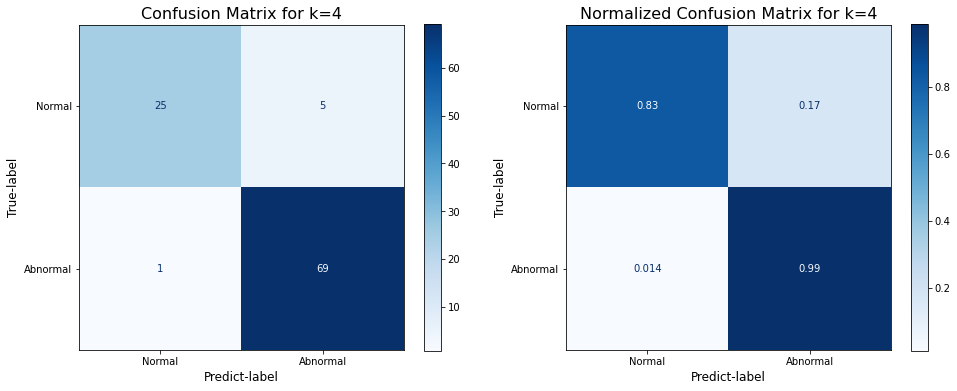

In [24]:
# Plot confusion matrix
fig, ax = plt.subplots(1,2,figsize=(16, 6))
plot_confusion_matrix(knn, X_test, y_test, cmap=plt.cm.Blues, normalize= None, ax=ax[0])
ax[0].set_title("Confusion Matrix for k=4",fontsize=16)
ax[0].set_xlabel('Predict-label',fontsize=12)
ax[0].set_ylabel('True-label',fontsize=12)
ax[0].set_xticklabels(['Normal', 'Abnormal'])
ax[0].set_yticklabels(['Normal', 'Abnormal'])

plot_confusion_matrix(knn, X_test, y_test, cmap=plt.cm.Blues, normalize='true', ax=ax[1]) 
ax[1].set_title("Normalized Confusion Matrix for k=4",fontsize=16)
ax[1].set_xlabel('Predict-label',fontsize=12)
ax[1].set_ylabel('True-label',fontsize=12)
ax[1].set_xticklabels(['Normal', 'Abnormal'])
ax[1].set_yticklabels(['Normal', 'Abnormal'])
plt.show()

In [25]:
# Calculate True Positive Case and True Negtive Case
confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
print(tn, fp, fn, tp) 

25 5 1 69


In [26]:
# Calculate True Positive Rate and True Negtive Rate
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1],normalize='true').ravel()
# print(tn, fp, fn, tp) 
pr = precision_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred)
# ac = accuracy_score(y_test, y_pred)
print("-"*55)
print("Model Report: ")
print("-"*55)
print( "True Positive Rate is : " + str(tp))
print( "True Negtive Rate is : " + str(tn))
print( "Precision is : " + str(pr))
print( "f1 score is : " + str(f1))
print("-"*55)

-------------------------------------------------------
Model Report: 
-------------------------------------------------------
True Positive Rate is : 0.9857142857142858
True Negtive Rate is : 0.8333333333333334
Precision is : 0.9324324324324325
f1 score is : 0.9583333333333333
-------------------------------------------------------


Other report

In [27]:
class_report = classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal'])

print("-"*55)
print("Report for Model File: ")
print("-"*55)
print(class_report)
print("-"*55)

-------------------------------------------------------
Report for Model File: 
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      0.83      0.89        30
    Abnormal       0.93      0.99      0.96        70

    accuracy                           0.94       100
   macro avg       0.95      0.91      0.93       100
weighted avg       0.94      0.94      0.94       100

-------------------------------------------------------


### (c)iii Since the computation time depends on the size of the training set, one may only use a subset of the training set. Plot the best test error rate, which is obtained by some value of k, against the size of training set, when the size of training set is N ∈ {10, 20, 30, ...., 210} 

In [28]:
# define set N
n_set = list(range(10, 211, 10))

best_test_error_rate={}
best_train_error_rate={}

knn = KNeighborsClassifier(metric = 'euclidean')
for n in tqdm(n_set):
    #subset training dataset
    df_NO_train_new = df_NO_train.iloc[0:math.floor(n/3)]
    df_AB_train_new = df_AB_train.iloc[0:(n-math.floor(n/3))]
    df_train_new = pd.concat([df_NO_train_new, df_AB_train_new], ignore_index=False).sort_index()
    X_train_new = df_train_new.drop("class", axis=1)
    y_train_new = df_train_new["class"]
    
    #apply knn on each k
    k_set = list(range(1, n+1, 5))
    result_list = []
    for k in k_set:
        result = knnclf(knn, k, X_train_new, X_test, y_train_new, y_test)
        result_list.append(result)
        
    df_temp = pd.DataFrame(result_list)
    min_test_error_rate = min(df_temp.test_error_rate)
    min_train_error_rate = min(df_temp.train_error_rate)
    
    min_test_ks = (df_temp.loc[df_temp.test_error_rate == min_test_error_rate]['k']).tolist()
    min_train_ks = (df_temp.loc[df_temp.train_error_rate == min_train_error_rate]['k']).tolist()
    best_test_error_rate[n]=(min_test_ks, min_test_error_rate)
    best_train_error_rate[n] = (k, min_train_error_rate)

# test error result
min_test_error_rate_ciii = min(best_test_error_rate.items(), key=lambda x: x[1][1])[1][1]
min_test_n = [key for key, value in best_test_error_rate.items() if value[1]==min_test_error_rate_ciii][0]
min_test_k_ciii = [value for key,value in best_test_error_rate.items() if value[1]==min_test_error_rate_ciii][0][0]
min_test_error_rates = list(zip(*list(best_test_error_rate.values())))[1]

# train error result
min_train_error_rate_ciii = min(best_train_error_rate.items(), key=lambda x: x[1][1])[1][1]

100%|██████████| 21/21 [00:11<00:00,  1.82it/s]


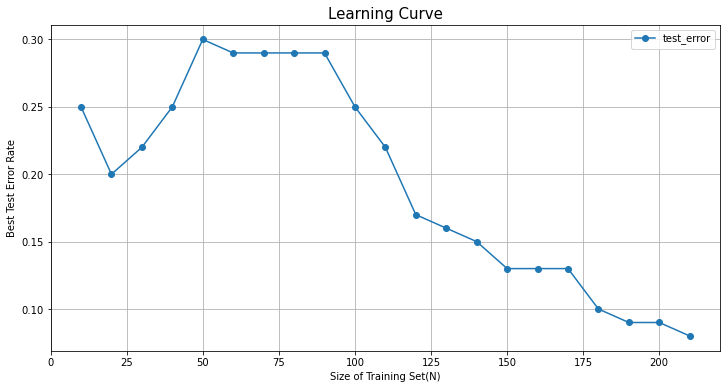

In [29]:
plt.figure(figsize=(12, 6))     
plt.plot(n_set, min_test_error_rates, marker='o', label="test_error")   
plt.grid(True)
plt.title("Learning Curve",fontsize=15)
plt.xlabel("Size of Training Set(N)")
plt.ylabel("Best Test Error Rate")
plt.legend(loc="upper right")
plt.show()

##### Table of K* at each N
In the event when there are multiple k-values with minimum test errors, pick the the smallest k value as the optimal k.

In [30]:
df_ciii = pd.DataFrame.from_dict(best_test_error_rate).T
df_ciii_1=df_ciii.reset_index()
df_ciii_report=df_ciii_1.rename(columns={"index": "N", 0: "k_candidates", 1:"mini_test_error_rate"})
df_ciii_report["k*"]=df_ciii_report.k_candidates.map(lambda x: x[0])
df_ciii_report

,N,k_candidates,mini_test_error_rate,k*
0,10,[1],0.25,1
1,20,[6],0.2,6
2,30,[1],0.22,1
3,40,[11],0.25,11
4,50,"[26, 31, 36, 41, 46]",0.3,26
5,60,[21],0.29,21
6,70,"[26, 31]",0.29,26
7,80,"[31, 36]",0.29,31
8,90,"[41, 46]",0.29,41
9,100,[6],0.25,6


In [31]:
print("-"*55)
print("Report for Minimum Error by using Euclidean Distance when N=N k = k*: ")
print("-"*55)
print("N*: " + str(min_test_n))
print("-"*55)
print("K*: " + str(min_test_k_ciii[0]))
print("-"*55)
print("Minimum test error rate: " + str(min_test_error_rate_ciii))
print("-"*55)

-------------------------------------------------------
Report for Minimum Error by using Euclidean Distance when N=N k = k*: 
-------------------------------------------------------
N*: 210
-------------------------------------------------------
K*: 6
-------------------------------------------------------
Minimum test error rate: 0.07999999999999996
-------------------------------------------------------


### (d) Replace the Euclidean metric with the following metrics5 and test them. Summarize the test errors (i.e., when k = k*) in a table. Use all of your training data and select the best k when {1, 6, 11, ......,196}.

#### A.Minkowski Distance (p=1)

In [32]:
k_set = list(range(1, 197, 5))

# declare classifier
knn = KNeighborsClassifier(metric = 'manhattan',p=1)
#apply knn at given k
result_list = []
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_dia = pd.DataFrame(result_list)


#calculate min k and min test error rate
min_test_error_rate_dia = min(df_dia.test_error_rate) 
min_test_error_dia = min(df_dia.test_error)
min_test_k_dia = (df_dia.loc[df_dia.test_error_rate == min_test_error_rate_dia]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_dia = min(df_dia.train_error_rate)
min_train_k_dia = (df_dia.loc[df_dia.train_error_rate == min_train_error_rate_dia]['k']).tolist()

# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 196, 'p': 1, 'weights': 'uniform'}


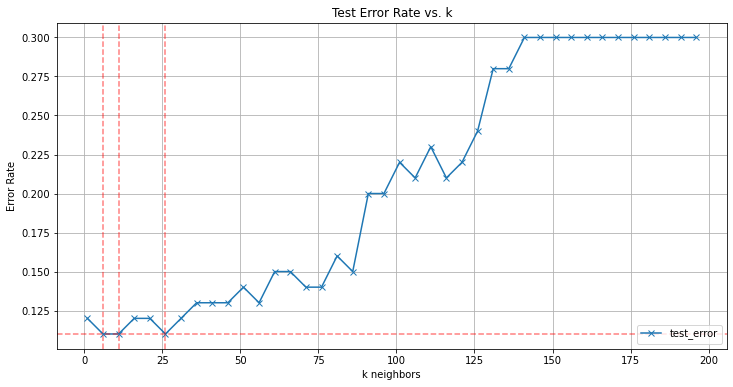

In [33]:
plt.figure(figsize=(12, 6))     

plt.plot(k_set, df_dia.test_error_rate, marker="x",label="test_error")
# plt.plot(k_set, df_dia.train_error, marker="o",label="train_error")

for v in min_test_k_dia:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_dia, color='r', alpha=0.5, linestyle='--')

plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [34]:
print("-"*55)
print("Report for Minimum Error by using Manhattan Distance when k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_dia[0]))
print("-"*55)
print("Minimum error: " + str(min_test_error_rate_dia))

-------------------------------------------------------
Report for Minimum Error by using Manhattan Distance when k = k*: 
-------------------------------------------------------
K*: 6
-------------------------------------------------------
Minimum error: 0.10999999999999999


#### B. with log10(p)  ∈ {0.1, 0.2, 0.3, ... ,1}. In this case, use the k* you found for the Manhattan distance in 1(d)iA. What is the best log10(p)?

In [35]:
log10p=np.arange(0.1, 1.1, 0.1)
p_values=10**log10p

temp_dict = {}
temp_dict2 = {}
dib_dict = {}
#apply knn at given k

for k in [min_test_k_dia[0]]:
    result_list = []
    min_error = []
    min_index = []
    for p in p_values:
        knn = KNeighborsClassifier(p=p)
        result = knnclf(knn, k, X_train, X_test, y_train, y_test)
        result_list.append(result)
        
    dib_dict[k] = result_list
    temp_df = pd.DataFrame(result_list)

    #calculate min k and min test error rate
    min_test_error_list=[x for x, x in enumerate(list(temp_df.test_error_rate)) if x==min(list(temp_df.test_error_rate))]
    min_test_index=[i for i, x in enumerate(list(temp_df.test_error_rate)) if x==min(list(temp_df.test_error_rate))]
    # save result in a dict
    temp_dict[k]= (min_test_error_list, min_test_index)

    
    #calculate min k and min train error rate
    min_train_error_list=[x for x, x in enumerate(list(temp_df.train_error_rate)) if x==min(list(temp_df.train_error_rate))]
    min_train_index=[i for i, x in enumerate(list(temp_df.train_error_rate)) if x==min(list(temp_df.train_error_rate))]
    # save result in a dict
    temp_dict2[k]= (min_train_error_list, min_train_index)

# confirm parameters
print(knn.get_params())
# find the minimum log10p and test error pair
min_test_error_rate_dib = min(temp_dict.values())[0][0] 
min_test_k_dib = [k for k, v in temp_dict.items() if v[0][0]==min_test_error_rate_dib]
min_test_log_index = [v[1] for k, v in temp_dict.items() if v[0][0]==min_test_error_rate_dib][0]
min_log10p = [log10p[i] for i in min_test_log_index]

# find the minimum log10p and train error pair
min_train_error_rate_dib = min(temp_dict2.values())[0][0] 

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 6, 'p': 10.0, 'weights': 'uniform'}


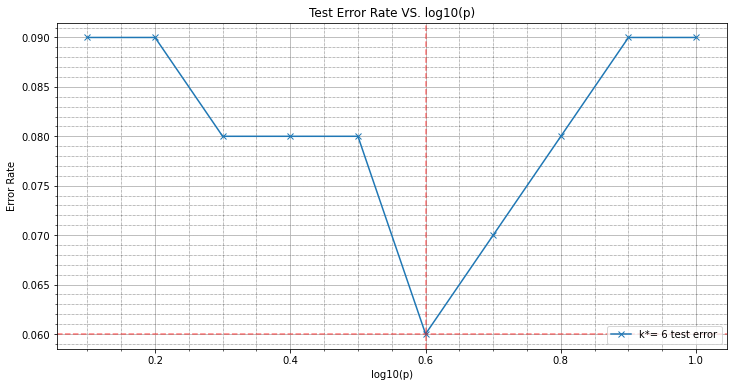

In [36]:
# making plot
plt.figure(figsize=(12, 6))  
df_dib = pd.DataFrame(dib_dict[min_test_k_dia[0]])
plt.plot(log10p, df_dib.test_error_rate ,marker="x",label="k*= {} test error".format(k))
# plt.plot(log10p, df_dib.train_error ,marker="o",label="k*= {} train error".format(k))
for v in min_log10p:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
# plt.axvline(min_log10p, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_dib, color='r', alpha=0.5,linestyle='--')
plt.title('Test Error Rate VS. log10(p)')
plt.xlabel('log10(p)')
plt.ylabel('Error Rate')
plt.grid(True)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.legend(loc="lower right")
plt.show()

In [37]:
print("-"*55)
print("Report for Minimum Error by using Minkowski Distance when k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_dib[0]))
print("-"*55)
print("Minimum test error rate: " + str(min_test_error_rate_dib))
print("-"*55)
print("Minimum log10P: " + str(min_log10p))
print("-"*55)

-------------------------------------------------------
Report for Minimum Error by using Minkowski Distance when k = k*: 
-------------------------------------------------------
K*: 6
-------------------------------------------------------
Minimum test error rate: 0.06000000000000005
-------------------------------------------------------
Minimum log10P: [0.6]
-------------------------------------------------------


#### C. Chebyshev Distance with p -> $\infty$

In [38]:
result_list = []
# declare classifier
knn = KNeighborsClassifier(metric='chebyshev',p=float('inf'))

#apply knn at given k
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_dic = pd.DataFrame(result_list)


#calculate min k and min test error rate
min_test_error_rate_dic = min(df_dic.test_error_rate) 
min_test_error_dic = min(df_dic.test_error)
min_test_k_dic = (df_dic.loc[df_dic.test_error_rate == min_test_error_rate_dic]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_dic = min(df_dic.train_error_rate)
min_train_k_dic = (df_dic.loc[df_dic.train_error_rate == min_train_error_rate_dic]['k']).tolist()

# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'chebyshev', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 196, 'p': inf, 'weights': 'uniform'}


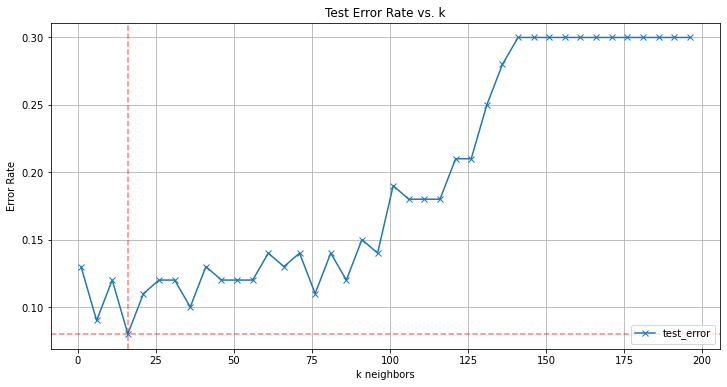

In [39]:
plt.figure(figsize=(12, 6))     

plt.plot(k_set, df_dic.test_error_rate, marker="x", label="test_error")
for v in min_test_k_dic:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_dic, color='r', alpha=0.5,linestyle='--')
plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [40]:
#Report
print("-"*55)
print("Report for Minimum Error by using Chebyshev Distance when k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_dic[0]))
print("-"*55)
print("Minimum test error rate: " + str(min_test_error_rate_dic))

-------------------------------------------------------
Report for Minimum Error by using Chebyshev Distance when k = k*: 
-------------------------------------------------------
K*: 16
-------------------------------------------------------
Minimum test error rate: 0.07999999999999996


### ii. Mahalanobis Distance

In [41]:
result_list = []
# declare classifier

# knn = KNeighborsClassifier(metric='mahalanobis', metric_params={'VI': pinv(np.cov(X_train))}, algorithm="brute")
knn = KNeighborsClassifier(metric='mahalanobis', metric_params={'VI': pinv(np.cov(X_train,rowvar=False))},algorithm="brute")

#apply knn at given k
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_dii = pd.DataFrame(result_list)


#calculate min k and min test error rate
min_test_error_rate_dii = min(df_dii.test_error_rate) 
min_test_error_dii = min(df_dii.test_error)
min_test_k_dii = (df_dii.loc[df_dii.test_error_rate == min_test_error_rate_dii]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_dii = min(df_dii.train_error_rate)
min_train_k_dii = (df_dii.loc[df_dii.train_error_rate == min_train_error_rate_dii]['k']).tolist()

# confirm parameters
print(knn.get_params())

{'algorithm': 'brute', 'leaf_size': 30, 'metric': 'mahalanobis', 'metric_params': {'VI': array([[ 3.54692478e+04, -3.54704192e+04,  4.81000029e-02,
        -3.54712632e+04, -8.86924243e-01,  4.22953063e-01],
       [-3.54704192e+04,  3.54716080e+04, -5.35124514e-02,
         3.54724416e+04,  8.88507001e-01, -4.24617105e-01],
       [ 4.81000028e-02, -5.35124514e-02,  8.04118769e-03,
        -5.54682958e-02, -1.81467220e-03,  3.60680605e-04],
       [-3.54712632e+04,  3.54724416e+04, -5.54682959e-02,
         3.54732952e+04,  8.91305985e-01, -4.25404422e-01],
       [-8.86924243e-01,  8.88507001e-01, -1.81467220e-03,
         8.91305985e-01,  8.80653540e-03, -6.72591602e-04],
       [ 4.22953063e-01, -4.24617105e-01,  3.60680605e-04,
        -4.25404422e-01, -6.72591602e-04,  1.18064473e-03]])}, 'n_jobs': -1, 'n_neighbors': 196, 'p': 2, 'weights': 'uniform'}


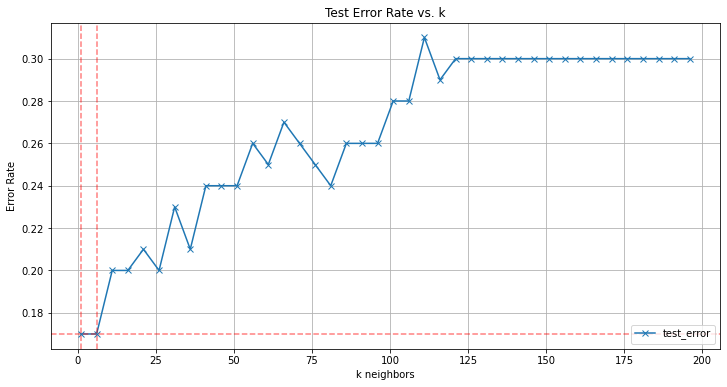

In [42]:
plt.figure(figsize=(12, 6))     
plt.plot(k_set, df_dii.test_error_rate, marker="x", label="test_error")
for v in min_test_k_dii:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_dii, color='r', alpha=0.5,linestyle='--')
plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [43]:
print("-"*55)
print("Report for Minimum Error by using Mahalanobis Distance when k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_dii[0]))
print("-"*55)
print("Minimum error: " + str(min_test_error_rate_dii))

-------------------------------------------------------
Report for Minimum Error by using Mahalanobis Distance when k = k*: 
-------------------------------------------------------
K*: 1
-------------------------------------------------------
Minimum error: 0.17000000000000004


#### Summary of part d

In [44]:
d_df = pd.DataFrame({'Distance':['Manhattan','log10P={}'.format(min_log10p),'Chebyshev','Mahalanobis'],\
                     'k*':[min_test_k_dia[0],min_test_k_dib[0],min_test_k_dic[0],min_test_k_dii[0]],\
                     'min_test_error_rate':[min_test_error_rate_dia,\
                                            min_test_error_rate_dib,\
                                            min_test_error_rate_dic,\
                                            min_test_error_rate_dii ]})
d_df

,Distance,k*,min_test_error_rate
0,Manhattan,6,0.11
1,log10P=[0.6],6,0.06
2,Chebyshev,16,0.08
3,Mahalanobis,1,0.17


### (e) The majority polling decision can be replaced by weighted decision, in which the weight of each point in voting is inversely proportional to its distance from the query/test data point.

* Euclidean

In [45]:
# declare classifier
knn = KNeighborsClassifier(metric ='euclidean',weights='distance')

result_list = []
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_ee = pd.DataFrame(result_list)

#calculate min k and min test error rate
min_test_error_rate_ee = min(df_ee.test_error_rate) 
min_test_error_ee = min(df_ee.test_error)
min_test_k_ee = (df_ee.loc[df_ee.test_error_rate == min_test_error_rate_ee]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_ee = min(df_ee.train_error_rate)
min_train_k_ee = (df_ee.loc[df_ee.train_error_rate == min_train_error_rate_cii]['k']).tolist()[0]

# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 196, 'p': 2, 'weights': 'distance'}


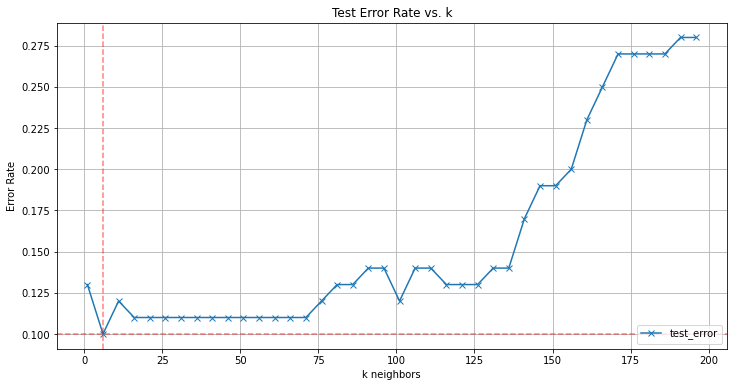

In [46]:
plt.figure(figsize=(12, 6))     
plt.plot(k_set, df_ee.test_error_rate, marker="x", label="test_error")
for v in min_test_k_ee:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
# plt.axvline(min_test_k_ee, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_ee, color='r', alpha=0.5,linestyle='--')
plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [47]:
print("-"*55)
print("Report for Minimum Error by using Euclidean Distance(Weighted Decision) when N=N k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_ee[0]))
print("-"*55)
print("Minimum error: " + str(min_test_error_rate_ee))

-------------------------------------------------------
Report for Minimum Error by using Euclidean Distance(Weighted Decision) when N=N k = k*: 
-------------------------------------------------------
K*: 6
-------------------------------------------------------
Minimum error: 0.09999999999999998


* Manhattan

In [48]:
# declare classifier
knn = KNeighborsClassifier(p=1, metric = 'manhattan', weights='distance')
#apply knn at given k
result_list = []
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_em = pd.DataFrame(result_list)


#calculate min k and min test error rate
min_test_error_rate_em = min(df_em.test_error_rate) 
min_test_error_em = min(df_em.test_error)
min_test_k_em = (df_em.loc[df_em.test_error_rate == min_test_error_rate_em]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_em = min(df_em.train_error_rate)
min_train_k_em = (df_em.loc[df_em.train_error_rate == min_train_error_rate_em]['k']).tolist()

# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 196, 'p': 1, 'weights': 'distance'}


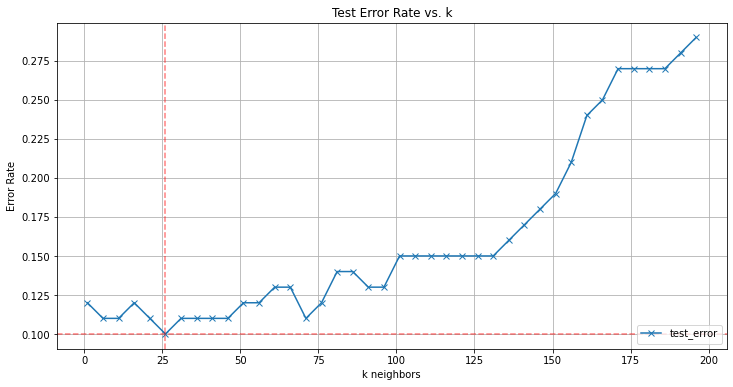

In [49]:
plt.figure(figsize=(12, 6))     
plt.plot(k_set, df_em.test_error_rate, marker="x", label="test_error")
for v in min_test_k_em:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
# plt.axvline(min_test_k_em, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_em, color='r', alpha=0.5,linestyle='--')
plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [50]:
print("-"*55)
print("Report for Minimum Error by using Manhattan Distance(Weighted Decision) when N=N k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_em[0]))
print("-"*55)
print("Minimum error: " + str(min_test_error_rate_em))

-------------------------------------------------------
Report for Minimum Error by using Manhattan Distance(Weighted Decision) when N=N k = k*: 
-------------------------------------------------------
K*: 26
-------------------------------------------------------
Minimum error: 0.09999999999999998


* Chebyshev distances

In [51]:
# declare classifier
knn = KNeighborsClassifier(metric='chebyshev',p=float('inf'),weights='distance')

result_list = []
#apply knn at given k
for k in k_set:
    result = knnclf(knn, k, X_train, X_test, y_train, y_test)
    result_list.append(result)
    
df_ec = pd.DataFrame(result_list)


#calculate min k and min test error rate
min_test_error_rate_ec = min(df_ec.test_error_rate) 
min_test_error_ec = min(df_ec.test_error)
min_test_k_ec = (df_ec.loc[df_ec.test_error_rate == min_test_error_rate_ec]['k']).tolist()

#calculate min k and min train error rate
min_train_error_rate_ec = min(df_ec.train_error_rate)
min_train_k_ec = (df_ec.loc[df_ec.train_error_rate == min_train_error_rate_ec]['k']).tolist()

# confirm parameters
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'chebyshev', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 196, 'p': inf, 'weights': 'distance'}


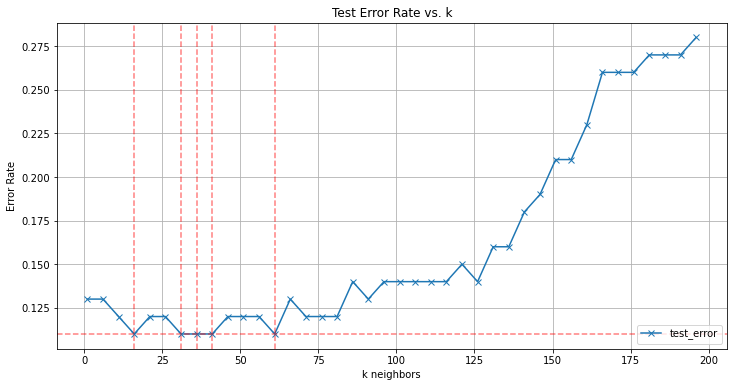

In [52]:
plt.figure(figsize=(12, 6))     
plt.plot(k_set, df_ec.test_error_rate, marker="x", label="test_error")
for v in min_test_k_ec:
    plt.axvline(v, color='r', alpha=0.5, linestyle='--')
# plt.axvline(min_test_k_ec, color='r', alpha=0.5, linestyle='--')
plt.axhline(min_test_error_rate_ec, color='r', alpha=0.5,linestyle='--')
plt.grid(True)
plt.title("Test Error Rate vs. k")
plt.xlabel("k neighbors")
plt.ylabel("Error Rate")
plt.legend(loc="lower right")
plt.show()

In [53]:
print("-"*55)
print("Report for Minimum Error by using Chebyshev Distance(Weighted Decision) when N=N k = k*: ")
print("-"*55)
print("K*: " + str(min_test_k_ec[0]))
print("-"*55)
print("Minimum error: " + str(min_test_error_rate_ec))

-------------------------------------------------------
Report for Minimum Error by using Chebyshev Distance(Weighted Decision) when N=N k = k*: 
-------------------------------------------------------
K*: 16
-------------------------------------------------------
Minimum error: 0.10999999999999999


In [54]:
e_df = pd.DataFrame({'Distance':['Euclidean', 'Manhattan','Chebyshev',],\
                     'k*':[min_test_k_ee[0], min_test_k_em[0], min_test_k_ec[0]],\
                     'min_test_error_rate':[min_test_error_rate_ee,\
                                            min_test_error_rate_em,\
                                            min_test_error_rate_ec]})
e_df

,Distance,k*,min_test_error_rate
0,Euclidean,6,0.10
1,Manhattan,26,0.10
2,Chebyshev,16,0.11


### (f) What is the lowest training error rate you achieved in this homework?

In [55]:
# Summary
f_df = pd.DataFrame({'Problem':['cii', 'ciii','diA','diB','diC','dii','e_Euclidean','e_Manhattan','e_Chebyshev' ],\
                     'min_train_error_rate':[min_train_error_rate_cii,\
                                            min_train_error_rate_ciii,\
                                            min_train_error_rate_dia,\
                                            min_train_error_rate_dib,\
                                            min_train_error_rate_dic,\
                                            min_train_error_rate_dii,\
                                            min_train_error_rate_ee,\
                                            min_train_error_rate_em,\
                                            min_train_error_rate_ec]})
f_df

,Problem,min_train_error_rate
0,cii,0.000000
1,ciii,0.000000
2,diA,0.000000
3,diB,0.133333
4,diC,0.000000
5,dii,0.000000
6,e_Euclidean,0.000000
7,e_Manhattan,0.000000
8,e_Chebyshev,0.000000


Based on the above train error rate table, the minimum train error rate is 0 in this homework